In [1]:
# ANÁLISIS DE VENTAS — SUPERSTORE DATASET
# Herramientas: Python, Pandas, Matplotlib, Seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('C:/Users/julia/Desktop/train.csv')
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("\nColumnas disponibles:")
print(df.columns.tolist())

Filas: 9800
Columnas: 18

Columnas disponibles:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [4]:
print("=== RESUMEN DEL DATASET ===")
print(f"Total de pedidos: {df.shape[0]:,}")
print(f"Total de ciudades: {df['City'].nunique()}")
print(f"Total de clientes: {df['Customer Name'].nunique()}")
print(f"Venta media: ${df['Sales'].mean():,.2f}")
print(f"Venta máxima: ${df['Sales'].max():,.2f}")
print(f"Venta mínima: ${df['Sales'].min():,.2f}")

=== RESUMEN DEL DATASET ===
Total de pedidos: 9,800
Total de ciudades: 529
Total de clientes: 793
Venta media: $230.77
Venta máxima: $22,638.48
Venta mínima: $0.44


In [5]:
# Preparo columnas de tiempo
df['Mes'] = pd.to_datetime(df['Order Date'], dayfirst=True).dt.month
df['Año'] = pd.to_datetime(df['Order Date'], dayfirst=True).dt.year

print("Años disponibles:", df['Año'].unique())
print("Meses disponibles:", df['Mes'].unique())

Años disponibles: [2017 2016 2015 2018]
Meses disponibles: [11  6 10  4 12  5  8  7  9  1  3  2]


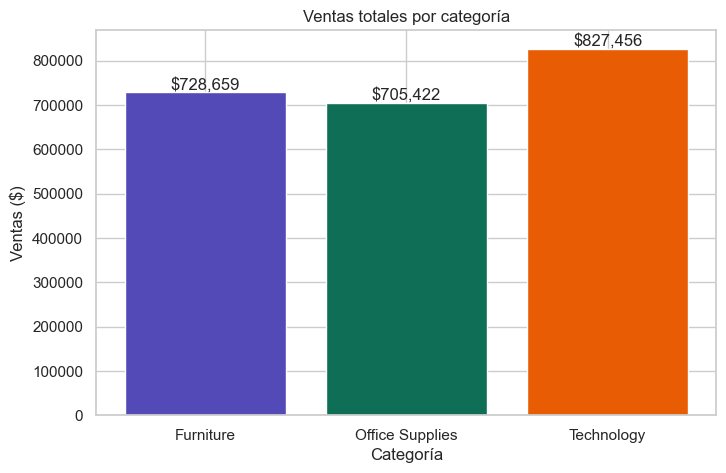

In [6]:
# GRÁFICO 1: Ventas totales por categoría
categoria_ventas = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8, 5))
barras = plt.bar(categoria_ventas.index, categoria_ventas.values,
                 color=['#534AB7', '#0F6E56', '#E85D04'])
plt.title('Ventas totales por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas ($)')
for barra in barras:
    valor = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, valor,
             f'${valor:,.0f}', ha='center', va='bottom')
plt.show()

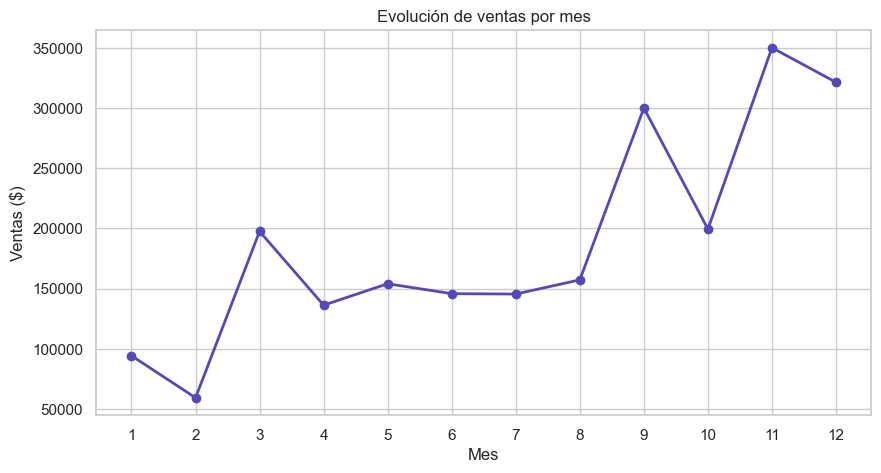

In [7]:
# GRÁFICO 2: Evolución de ventas por mes
ventas_por_mes = df.groupby('Mes')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(ventas_por_mes.index, ventas_por_mes.values,
         color='#534AB7', linewidth=2, marker='o')
plt.title('Evolución de ventas por mes')
plt.xlabel('Mes')
plt.ylabel('Ventas ($)')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12])
plt.show()

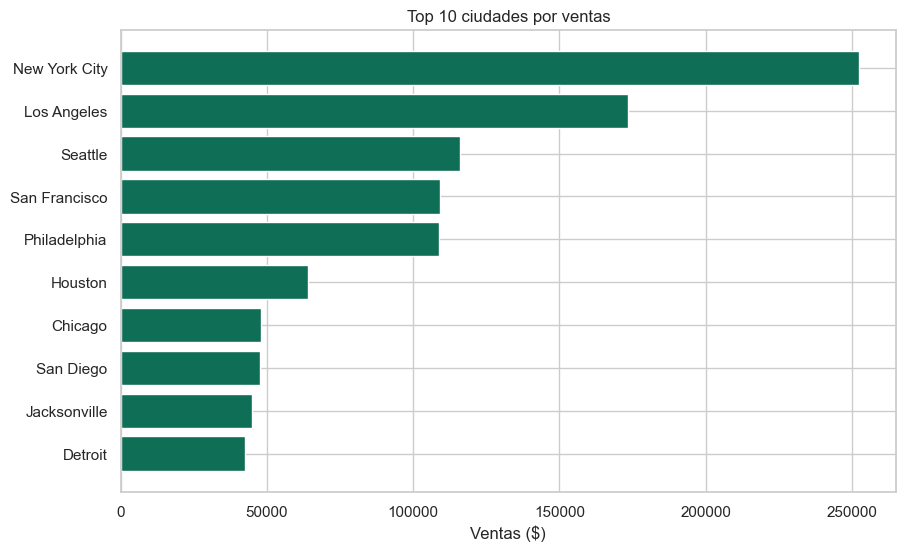

In [6]:
# GRÁFICO 3: Top 10 ciudades por ventas
top_ciudades = df.groupby('City')['Sales'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_ciudades.index, top_ciudades.values, color='#0F6E56')
plt.title('Top 10 ciudades por ventas')
plt.xlabel('Ventas ($)')
plt.show()

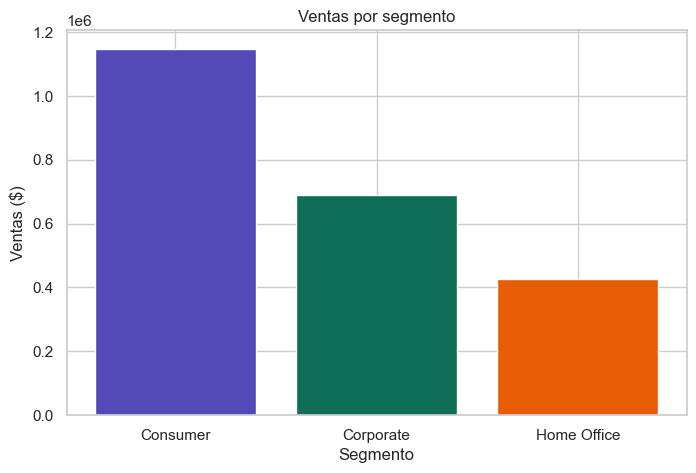

In [8]:
#GRÁFICO 4: Ventas por segmento
segmento_ventas = df.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(8, 5))
barras = plt.bar(segmento_ventas.index, segmento_ventas.values,
                 color=['#534AB7', '#0F6E56', '#E85D04'])
plt.title('Ventas por segmento')
plt.xlabel('Segmento')
plt.ylabel('Ventas ($)')
plt.show()

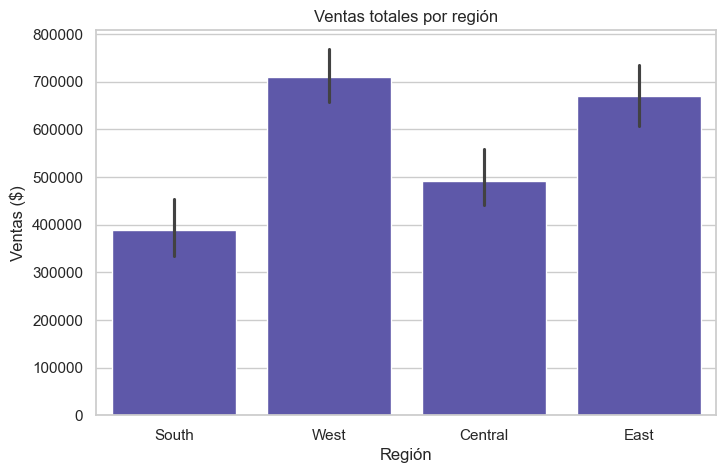

In [9]:
# GRÁFICO 5: Ventas por región
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Region', y='Sales', 
            estimator='sum', color='#534AB7')
plt.title('Ventas totales por región')
plt.xlabel('Región')
plt.ylabel('Ventas ($)')
plt.show()

In [10]:
print("""
=== CONCLUSIONES DEL ANÁLISIS ===

1. CATEGORÍA MÁS RENTABLE
   Technology es la categoría con más ventas totales,
   seguida de Furniture y Office Supplies.

2. ESTACIONALIDAD
   Noviembre es el mes con más ventas, probablemente
   por el Black Friday. Se recomienda reforzar stock
   y campañas de marketing en octubre-noviembre.

3. CIUDADES CLAVE
   New York, Los Angeles y Seattle concentran
   la mayor parte de las ventas. Son mercados
   prioritarios para la empresa.

4. SEGMENTO PRINCIPAL
   Consumer es el segmento que más compra (50%+),
   seguido de Corporate y Home Office.

5. REGIÓN MÁS FUERTE
   West es la región con más ventas totales.
""")


=== CONCLUSIONES DEL ANÁLISIS ===

1. CATEGORÍA MÁS RENTABLE
   Technology es la categoría con más ventas totales,
   seguida de Furniture y Office Supplies.

2. ESTACIONALIDAD
   Noviembre es el mes con más ventas, probablemente
   por el Black Friday. Se recomienda reforzar stock
   y campañas de marketing en octubre-noviembre.

3. CIUDADES CLAVE
   New York, Los Angeles y Seattle concentran
   la mayor parte de las ventas. Son mercados
   prioritarios para la empresa.

4. SEGMENTO PRINCIPAL
   Consumer es el segmento que más compra (50%+),
   seguido de Corporate y Home Office.

5. REGIÓN MÁS FUERTE
   West es la región con más ventas totales.

